In [129]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import arviz as az
import xarray as xr
from scipy.linalg import null_space

from _utils_spline import eval_spline_basis_equispaced_numeric, difference_matrix

import warnings
warnings.filterwarnings('ignore')

In [3]:
replications = 500

In [81]:
# True values
def f1(x):
    return x/1.758
def f2(x):
    return x**2/2.75 - 1.5
def f3(x):
    return np.sin(x)/0.72

f_value = [f1, f2, f3]
sigma_value = [1, 0.5, 0.33]

f_sigma_value = list(zip(f_value, sigma_value))

In [82]:
# Generating data
data = {(f.__name__, sigma): {} for f, sigma in f_sigma_value}

n = 100
for f, sigma in f_sigma_value:
    for i in range(replications):
        x = np.random.uniform(-3, 3, n)
        f_evaluated = f(x)
        f_evaluated /= np.std(f_evaluated)
        y = f_evaluated + np.random.normal(0, sigma, n)
        data[(f.__name__, sigma)][i] = (x, y)


In [75]:
model_data = data[('f1', 0.33)][0]
x_data = model_data[0]
x_data_order = np.argsort(x_data)
y_data = model_data[1]

a = 1
b = 0.005

In [141]:
spline_degree = 3
pen_order = 2
n_internal_knots = 20

implementation = 'standard'
implementation = 'centring+dropping'
implementation = 'conditioning'
penalised = True
order = 2

def D(w, k, order, exact):
    if exact:
        raise NotImplementedError("Exact implementation not implemented")
    else:
        Dw = difference_matrix(k, order=order) @ w
        return pt.dot(Dw, Dw)


In [77]:
model = pm.Model()
with model:
    # Priors
    beta_0 = pm.Normal('beta_0', mu=0, sigma=100)
    sigma_2 = pm.InverseGamma('sigma_2', alpha=a, beta=b)

    tau = pm.Gamma("tau", alpha=a, beta=b)
    #tau = pm.Deterministic("tau", pt.as_tensor_variable(1.0))
    if penalised:
        #tau_p = pm.Gamma("tau_p", alpha=a, beta=b)
        tau_p = pm.Deterministic("tau_p", pt.as_tensor_variable(1.0))

    # Spline implementation
    eval_B = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_data)
    B = eval_B['B']
    k = B.shape[1]
    K = difference_matrix(k, order=order).T @ difference_matrix(k, order=order)
    if implementation=='standard':
        X = B.copy()
        if penalised:
            Q = tau_p * K + tau * np.eye(k)
        else:
            Q =tau * np.eye(k)
        w = pm.MvNormal("w", mu=np.zeros(k), tau=Q, shape=k)
        f = pm.math.dot(X, w)

    eta = beta_0 + f
    # Likelihood
    y_obs = pm.Normal('y_obs', mu=eta, sigma=np.sqrt(sigma_2), observed=y_data)

In [143]:
model = pm.Model()
with model:
    # Priors
    beta_0 = pm.Normal('beta_0', mu=0, sigma=100)
    sigma_2 = pm.InverseGamma('sigma_2', alpha=a, beta=b)

    tau = pm.Gamma("tau", alpha=a, beta=b)
    #tau = pm.Deterministic("tau", pt.as_tensor_variable(1.0))
    if penalised:
        tau_p = pm.Gamma("tau_p", alpha=a, beta=b)
        #tau_p = pm.Deterministic("tau_p", pt.as_tensor_variable(1.0))

    # Spline implementation
    eval_B = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_data)
    B = eval_B['B']
    k = B.shape[1]

    if implementation=='standard': # standard = full B splines, unidentifiable, use for posterior centring evaluation
        X = B.copy()
        w = pm.Normal("w",mu=0, tau=tau, shape=k, dims="w_dim")
        if penalised:
            Dw = pt.dot(difference_matrix(k, order=order), w)
            K = difference_matrix(k, order=order).T @ difference_matrix(k, order=order)
            penalty = pt.dot(Dw, Dw)
            Q = tau_p * K + tau * np.eye(k)
            sign, logdet = pt.linalg.slogdet(Q)
            pm.Potential("spline_penalty", - 0.5 * tau_p * penalty
                                           - 0.5 * k * pt.log(tau)
                                           + 0.5 * logdet)
        f = pm.math.dot(X, w)

    elif implementation=='centring+dropping': # centring+dropping = Gressani implementation, adjusted penalty
        X = B.copy()
        X = X - X.mean(axis=0)  # centre the basis functions
        X = X[:, :-1]  # drop the last column to ensure identifiability

        w = pm.Normal("w",mu=0, tau=tau, shape=k-1, dims="w_dim")
        if penalised:
            Dw = pt.dot(difference_matrix(k, order=order)[:, :-1], w)
            K = difference_matrix(k, order=order)[:, :-1].T @ difference_matrix(k, order=order)[:, :-1]
            penalty = pt.dot(Dw, Dw)
            Q = tau_p * K + tau * np.eye(k-1)
            sign, logdet = pt.linalg.slogdet(Q)
            pm.Potential("spline_penalty", - 0.5 * tau_p * penalty
                                           - 0.5 * (k-1) * pt.log(tau)
                                           + 0.5 * logdet)
        f = pm.math.dot(X, w)

    elif implementation=='conditioning': # conditioning = Chen implementation, map to constrained conditioned space
        X = B.copy()
        Z = null_space(np.ones((X.shape[0], 1)).T @ X)
        ZTZ = Z.T @ Z
        print(Z.shape)
        theta = pm.MvNormal("theta", mu=np.zeros(Z.shape[1]), tau=tau*ZTZ, shape=Z.shape[1], dims="theta_dim")

        model.add_coord("w_dim", range(k))
        w = pm.Deterministic("w", pt.dot(Z,theta), dims="w_dim")
        if penalised:
            Dw = pt.dot(difference_matrix(k, order=order)[:, :], w)
            K = difference_matrix(k, order=order)[:, :].T @ difference_matrix(k, order=order)[:, :]
            penalty = pt.dot(Dw, Dw)
            Q = tau_p * K + tau * np.eye(k)
            sign, logdet = pt.linalg.slogdet(Q)
            pm.Potential("spline_penalty", - 0.5 * tau_p * penalty
                                           - 0.5 * (k-1) * pt.log(tau)
                                           + 0.5 * logdet)
        f = pm.math.dot(X, w)

    eta = beta_0 + f
    # Likelihood
    y_obs = pm.Normal('y_obs', mu=eta, sigma=np.sqrt(sigma_2), observed=y_data)

(24, 23)


In [144]:
n_tune = 1000
n_draws = 1000
n_chains = 4
n_cores = 4

In [145]:
with model:
    idata = pm.sample(tune = n_tune,
                    draws = n_draws,
                    chains = n_chains,
                    random_seed=42,
                    cores = n_cores,
                    discard_tuned_samples=True,
                    progressbar=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, sigma_2, tau, tau_p, theta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 539 seconds.


In [105]:
idata.posterior

<xarray.Dataset> Size: 2MB
Dimensions:     (chain: 4, draw: 1000, w_dim_0: 24)
Coordinates:
  * chain       (chain) int64 32B 0 1 2 3
  * draw        (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
  * w_dim_0     (w_dim_0) int64 192B 0 1 2 3 4 5 6 7 ... 16 17 18 19 20 21 22 23
Data variables:
    beta_0      (chain, draw) float64 32kB 0.2452 0.08916 ... -0.8158 -0.8268
    w           (chain, draw, w_dim_0) float64 768kB -2.465 -2.267 ... 2.568
    sigma_2     (chain, draw) float64 32kB 0.1001 0.1251 ... 0.1297 0.1289
    tau         (chain, draw) float64 32kB 0.1469 0.04133 ... 0.126 0.1404
    tau_p       (chain, draw) float64 32kB 321.2 246.9 263.7 ... 126.1 131.2
    w_centered  (chain, draw, w_dim_0) float64 768kB -2.206 -2.008 ... 1.727
Attributes:
    created_at:                 2026-05-14T02:41:37.542864+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              283.92243695259094
    tuning_steps:               1000

In [102]:
w_post = idata.posterior["w"]

w_centered = w_post - w_post.mean(dim="w_dim_0")  # adjust dim name if needed

idata.posterior["w_centered"] = w_centered

In [148]:
az.summary(idata, var_names=['sigma_2', 'tau','w'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_2,0.115,0.017,0.086,0.147,0.000,0.000,4348.0,2823.0,1.00
tau,0.135,0.099,0.005,0.317,0.002,0.002,3617.0,2031.0,1.00
w[0],-2.214,0.241,-2.662,-1.770,0.008,0.005,979.0,1316.0,1.01
w[1],-1.992,0.162,-2.289,-1.692,0.005,0.003,987.0,1425.0,1.01
w[2],-1.768,0.112,-1.961,-1.541,0.003,0.002,1195.0,1776.0,1.00
w[3],-1.547,0.086,-1.710,-1.388,0.002,0.002,1781.0,2487.0,1.00
w[4],-1.334,0.077,-1.482,-1.191,0.002,0.001,2141.0,2445.0,1.00
w[5],-1.138,0.072,-1.276,-1.005,0.001,0.001,2608.0,2042.0,1.00
w[6],-0.949,0.068,-1.078,-0.821,0.001,0.001,2906.0,1962.0,1.00
w[7],-0.766,0.066,-0.881,-0.633,0.001,0.001,3003.0,2548.0,1.00


In [149]:
x_plot = np.linspace(np.min(x_data), np.max(x_data), 500)
eval_B_plot = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_plot)
B_plot = eval_B_plot['B'][:, :]
interior_knots = eval_B_plot['interior_knots']
B_post = np.dot(B_plot, idata.posterior['w'].values.reshape(n_chains*n_draws, k).T)
B_post = B_post - np.mean(B_post, axis=0)
B_post_mean = B_post.mean(axis=1)
B_post_median = np.median(B_post, axis=1)
B_post_975 = np.percentile(B_post, 97.5, axis=1)
B_post_025 = np.percentile(B_post, 2.5, axis=1)

In [125]:
x_plot = np.linspace(np.min(x_data), np.max(x_data), 500)
eval_B_plot = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_plot)
B_plot = eval_B_plot['B'][:, :-1]
interior_knots = eval_B_plot['interior_knots']
B_post = np.dot(B_plot, idata.posterior['w'].values.reshape(n_chains*n_draws, k-1).T)
B_post = B_post - np.mean(B_post, axis=0)
B_post_mean = B_post.mean(axis=1)
B_post_median = np.median(B_post, axis=1)
B_post_975 = np.percentile(B_post, 97.5, axis=1)
B_post_025 = np.percentile(B_post, 2.5, axis=1)

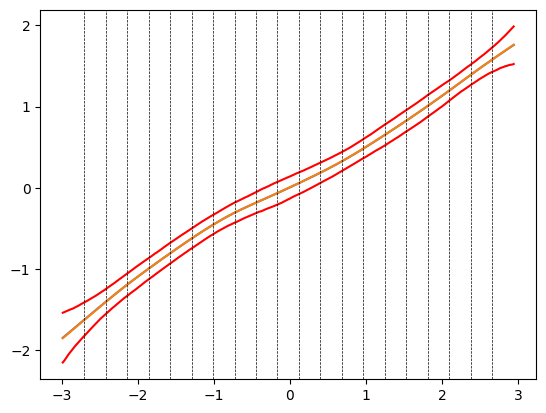

In [150]:
plt.plot(x_plot, B_post_mean[:])
plt.plot(x_plot, B_post_median[:])
plt.plot(x_plot, B_post_975[:], c='r')
plt.plot(x_plot, B_post_025[:], c='r')
for knot in interior_knots:
    plt.axvline(knot, c='k', ls='--', lw=0.5)
plt.show()

ValueError: x and y must have same first dimension, but have shapes (100,) and (500,)

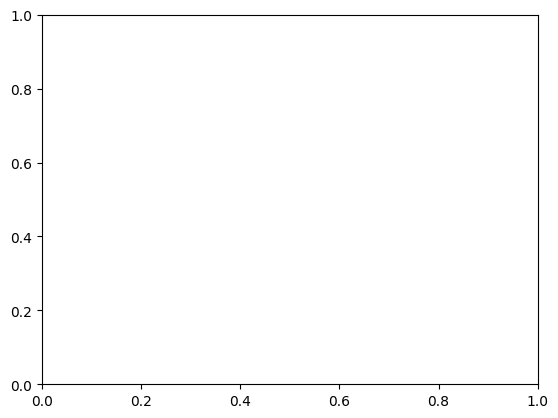

In [ ]:
plt.plot(x_data[x_data_order], B_post_mean[x_data_order])
plt.plot(x_data[x_data_order], B_post_median[x_data_order])
plt.plot(x_data[x_data_order], B_post_975[x_data_order], c='r')
plt.plot(x_data[x_data_order], B_post_025[x_data_order], c='r')
plt.show()